# 01. Anomaly Detection for Decision Science

Anomaly detection is often introduced as the task of finding unusual observations. For decision science, that definition is only the beginning. A production anomaly detector is not valuable because it labels points as strange. It is valuable when it helps an organization decide what to review, what to suppress, what to escalate, what to investigate, and what to redesign.

This lecture frames anomaly detection as a decision system under incomplete evidence. We will use a synthetic payment-operations case study to connect the core statistical idea of unusualness to alert thresholds, review capacity, false alarms, missed incidents, contextual baselines, and analyst-facing explanations.

The central theme is simple: an anomaly score is not a decision. A decision requires a threshold, a cost model, a workflow, and a governance standard.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Define anomaly detection as a score-and-action problem rather than only an algorithmic task.
2. Distinguish point anomalies, contextual anomalies, and collective anomalies.
3. Write a mathematical decision rule that turns anomaly scores into alerts.
4. Explain why thresholds depend on review capacity, base rates, and asymmetric error costs.
5. Build a realistic synthetic anomaly-detection dataset with known anomaly labels for teaching.
6. Compare naive, contextual, and composite anomaly scores.
7. Interpret precision, recall, alert volume, and expected utility for anomaly detection.
8. Translate anomaly detection results into an operational review recommendation.

In [1]:
# Section focus: Learning Objectives.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 160)

RANDOM_SEED = 2026

## 1. From Unusualness to Decision Support

A useful mathematical skeleton for anomaly detection is

$$
s_i = g(x_i), \qquad d_i(t) = \mathbf{1}\{s_i \ge t\},
$$

where:

- $x_i$ is the observed feature vector for case $i$,
- $g(x_i)$ is an anomaly score,
- $t$ is an alert threshold,
- $d_i(t)$ is the decision to alert or not alert.

The statistical question is whether $s_i$ captures meaningful deviation from a relevant baseline. The decision question is whether alerting at threshold $t$ improves the workflow.

Anomaly detection therefore involves two linked problems:

$$
\text{score construction: } g(x), \qquad
\text{policy construction: } \delta_t(s) = \mathbf{1}\{s \ge t\}.
$$

The score can be statistical, distance-based, density-based, reconstruction-based, model-based, or hybrid. But the policy must still answer a practical question: how many cases can the team review, and what kinds of mistakes matter most?

| Decision-system element | Question to answer | Example in anomaly detection |
|---|---|---|
| Unit of analysis | What object can be alerted? | Transaction, account-day, machine-hour, claim, shipment, login session |
| Normal baseline | Normal relative to what? | Peer group, season, account history, operating context, recent trend |
| Anomaly score | How unusual is the case? | Distance, tail probability, residual, isolation score, reconstruction error |
| Alert policy | Which cases enter review? | Score threshold, top-k queue, segment-specific threshold, human override rule |
| Cost model | What happens if we are wrong? | False alarm cost, missed incident cost, investigation cost, service risk |
| Feedback loop | How will we learn after alerting? | Analyst labels, incident outcomes, suppression reasons, review notes |

### Literature Anchor

Classic surveys emphasize that anomaly, outlier, novelty, deviation, and exception detection often refer to overlapping problems, even though different fields use different names (Hodge & Austin, 2004). Chandola et al. (2009) organize anomaly detection across application domains and distinguish settings where anomalous observations occupy low-probability or behaviorally unusual regions. In streaming settings, threshold choice becomes especially important because manually chosen thresholds can be brittle under changing baselines (Siffer et al., 2017).

That literature is useful, but this course will keep returning to the decision-system layer: an anomaly detector is a component inside a larger workflow.

## 2. A Taxonomy of Anomalies

Different anomaly types require different baselines. A case can be unusual in isolation, unusual only within context, or unusual as part of a sequence.

| Anomaly type | Informal definition | Example | Main baseline question |
|---|---|---|---|
| Point anomaly | A single observation is unusual by itself | A transaction amount is 50 times larger than typical transactions | Is this value rare globally? |
| Contextual anomaly | A value is unusual given its context | A \$500 transaction is normal for enterprise vendors but abnormal for a new small vendor | Is this value rare for this peer group or situation? |
| Collective anomaly | A group or pattern is unusual even if each part is not extreme | Ten nearly identical invoices arrive within a short window | Is this sequence or cluster abnormal as a set? |

This distinction matters because a global detector can miss contextual anomalies, while a purely local detector can over-alert when a whole system shifts.

### Mathematical View of Baselines

Let $X$ denote a feature vector and $C$ denote context. A global anomaly score might estimate a tail event under a single normal distribution:

$$
s_{\mathrm{global}}(x) = -\log \hat p(x).
$$

A contextual detector instead asks whether $x$ is unusual conditional on context:

$$
s_{\mathrm{context}}(x, c) = -\log \hat p(x \mid C=c).
$$

A residual-based version is common in practice. If a baseline model predicts an expected value

$$
\hat m(c) \approx \mathbb{E}[Y \mid C=c],
$$

then a contextual anomaly score can be based on the standardized residual

$$
r_i = \frac{y_i - \hat m(c_i)}{\hat\sigma(c_i)}, \qquad s_i = |r_i|.
$$

This framing will be important throughout the course: anomaly detection is often about choosing the right comparison set.

## 3. Synthetic Case Study: Payment Operations Review

Imagine a payment platform that reviews business-to-business transactions. The operations team wants to detect transactions that deserve analyst review before settlement. The alert budget is limited, so every unusual-looking transaction cannot be reviewed.

We will simulate transaction-level data with four groups:

| Group | Meaning | Detection challenge |
|---|---|---|
| Normal | Transaction follows expected operational pattern | Should usually not alert |
| Amount spike | Transaction is unusually large relative to vendor context | A contextual detector should catch it |
| Risky access | Transaction occurs with unusual access and geographic risk | A composite score should catch it |
| Duplicate burst | Transaction resembles repeated invoices in a short window | A collective pattern should be flagged |

In real applications, true anomaly labels are incomplete and delayed. Here we create labels only so that the lecture can evaluate scores clearly.

In [2]:
# Section focus: 3. Synthetic Case Study: Payment Operations Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1.0 / (1.0 + np.exp(-z))


def robust_z(series):
    """Carry out the robust z step used in the 01. Anomaly Detection for Decision Science workflow.
    
    Parameters
    ----------
    series : object
        One-dimensional pandas object whose distribution or most common value is being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the robust z calculation and reused by later cells.
    """
    median = np.median(series)
    mad = np.median(np.abs(series - median))
    scale = 1.4826 * mad if mad > 0 else np.std(series)
    return (series - median) / scale


def simulate_payment_operations(n=7200, seed=RANDOM_SEED):
    """Create a simulated payment operations data set for the 01. Anomaly Detection for Decision Science case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the payment operations calculation and reused by later cells.
    """
    rng = np.random.default_rng(seed)

    vendor_segment = rng.choice(
        ['small_vendor', 'mid_market_vendor', 'enterprise_vendor'],
        size=n,
        p=[0.52, 0.33, 0.15],
    )
    channel = rng.choice(['api', 'portal', 'batch_upload'], size=n, p=[0.45, 0.38, 0.17])
    weekday = rng.integers(0, 7, size=n)
    hour = rng.integers(0, 24, size=n)

    segment_scale = np.select(
        [vendor_segment == 'small_vendor', vendor_segment == 'mid_market_vendor', vendor_segment == 'enterprise_vendor'],
        [0.0, 0.75, 1.45],
    )
    channel_effect = np.select(
        [channel == 'api', channel == 'portal', channel == 'batch_upload'],
        [0.08, 0.00, 0.22],
    )
    weekend_effect = 0.18 * (weekday >= 5)

    vendor_history_months = np.clip(
        rng.gamma(shape=2.0 + 0.6 * segment_scale, scale=8.0, size=n),
        1,
        96,
    )
    vendor_prior_volume = np.clip(
        rng.lognormal(mean=2.0 + 0.75 * segment_scale, sigma=0.55, size=n),
        2,
        260,
    )
    account_tenure_months = np.clip(vendor_history_months + rng.normal(10, 8, n), 1, 130)

    expected_log_amount = (
        5.10
        + 0.72 * segment_scale
        + 0.21 * np.log1p(vendor_prior_volume)
        + 0.12 * np.log1p(vendor_history_months)
        + channel_effect
        + weekend_effect
    )
    log_amount = expected_log_amount + rng.normal(0, 0.45, n)

    country_risk = np.clip(rng.beta(1.6, 8.5, n) + 0.05 * (channel == 'batch_upload'), 0, 1)
    device_risk = np.clip(rng.beta(1.4, 9.0, n) + 0.08 * (hour < 5), 0, 1)
    invoice_similarity = np.clip(rng.beta(2.2, 5.8, n), 0, 1)
    recent_vendor_count = rng.poisson(1.2 + 0.012 * vendor_prior_volume + 0.8 * (channel == 'batch_upload'))

    anomaly_type = np.array(['normal'] * n, dtype=object)
    u = rng.random(n)
    amount_mask = u < 0.018
    risky_access_mask = (u >= 0.018) & (u < 0.031)
    duplicate_mask = (u >= 0.031) & (u < 0.046)

    log_amount[amount_mask] += rng.normal(1.65, 0.35, amount_mask.sum())
    anomaly_type[amount_mask] = 'amount_spike'

    country_risk[risky_access_mask] = np.clip(country_risk[risky_access_mask] + rng.uniform(0.45, 0.75, risky_access_mask.sum()), 0, 1)
    device_risk[risky_access_mask] = np.clip(device_risk[risky_access_mask] + rng.uniform(0.45, 0.75, risky_access_mask.sum()), 0, 1)
    hour[risky_access_mask] = rng.choice([0, 1, 2, 3, 4, 23], size=risky_access_mask.sum())
    anomaly_type[risky_access_mask] = 'risky_access'

    invoice_similarity[duplicate_mask] = np.clip(invoice_similarity[duplicate_mask] + rng.uniform(0.45, 0.70, duplicate_mask.sum()), 0, 1)
    recent_vendor_count[duplicate_mask] += rng.poisson(7, duplicate_mask.sum()) + 4
    anomaly_type[duplicate_mask] = 'duplicate_burst'

    amount = np.exp(log_amount)
    true_anomaly = (anomaly_type != 'normal').astype(int)

    data = pd.DataFrame({
        'vendor_segment': vendor_segment,
        'channel': channel,
        'weekday': weekday,
        'hour': hour,
        'vendor_history_months': vendor_history_months,
        'vendor_prior_volume': vendor_prior_volume,
        'account_tenure_months': account_tenure_months,
        'amount': amount,
        'log_amount': log_amount,
        'country_risk': country_risk,
        'device_risk': device_risk,
        'invoice_similarity': invoice_similarity,
        'recent_vendor_count': recent_vendor_count,
        'expected_log_amount': expected_log_amount,
        'anomaly_type': anomaly_type,
        'true_anomaly': true_anomaly,
    })
    return data


df = simulate_payment_operations()
preview_cols = [
    'vendor_segment', 'channel', 'weekday', 'hour', 'amount', 'vendor_prior_volume',
    'country_risk', 'device_risk', 'invoice_similarity', 'recent_vendor_count',
    'anomaly_type', 'true_anomaly',
]
smart_display(df[preview_cols].head(), max_width='120px')

,vendor_segment,channel,weekday,hour,amount,vendor_prior_volume,country_risk,device_risk,invoice_similarity,recent_vendor_count,anomaly_type,true_anomaly
0,small_vendor,portal,3,0,509.486009,3.065665,0.708433,0.685924,0.158814,2,risky_access,1
1,mid_market_vendor,batch_upload,2,13,930.888487,5.717127,0.182541,0.289523,0.113244,1,normal,0
2,small_vendor,api,6,14,494.710778,4.692942,0.203440,0.042626,0.318782,0,normal,0
3,small_vendor,batch_upload,0,4,584.259284,9.847364,0.164520,0.123991,0.367673,3,normal,0
4,small_vendor,portal,0,9,415.019147,14.697148,0.067109,0.013771,0.077974,3,normal,0


For Synthetic Case Study: Payment Operations Review, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


In [3]:
# Section focus: 3. Synthetic Case Study: Payment Operations Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

overview = pd.DataFrame({
    'Quantity': [
        'Transactions',
        'Known anomaly rate',
        'Median amount',
        '90th percentile amount',
        'Average country risk',
        'Average device risk',
        'Average recent vendor count',
    ],
    'Value': [
        len(df),
        df['true_anomaly'].mean(),
        df['amount'].median(),
        df['amount'].quantile(0.90),
        df['country_risk'].mean(),
        df['device_risk'].mean(),
        df['recent_vendor_count'].mean(),
    ],
})

anomaly_mix = (
    df['anomaly_type']
    .value_counts(normalize=False)
    .rename_axis('anomaly_type')
    .reset_index(name='count')
)
anomaly_mix['share'] = anomaly_mix['count'] / len(df)

overview_display = overview.copy()
overview_display['Value'] = overview_display['Value'].map(lambda value: f'{value:,.0f}' if abs(value) >= 1000 else f'{value:.3f}')

anomaly_mix_display = anomaly_mix.copy()
anomaly_mix_display['share'] = anomaly_mix_display['share'].map(lambda value: f'{value:.1%}')

smart_display(overview_display, max_width='420px')
smart_display(anomaly_mix_display, max_width='360px')

,Quantity,Value
0,Transactions,"7,200"
1,Known anomaly rate,0.047
2,Median amount,598.885
3,90th percentile amount,"1,648"
4,Average country risk,0.174
5,Average device risk,0.160
6,Average recent vendor count,1.629


,anomaly_type,count,share
0,normal,6862,95.3%
1,amount_spike,147,2.0%
2,risky_access,102,1.4%
3,duplicate_burst,89,1.2%


The anomaly base rate is intentionally low. This is the first operational difficulty. If only a few percent of cases are truly problematic, even a useful detector can create many false alarms unless thresholds are designed carefully.

The dataset also mixes anomaly mechanisms. A transaction can be suspicious because it is large for its vendor context, because the access pattern looks risky, or because it participates in a repeated-invoice pattern. A single univariate amount rule will not handle all three mechanisms well.

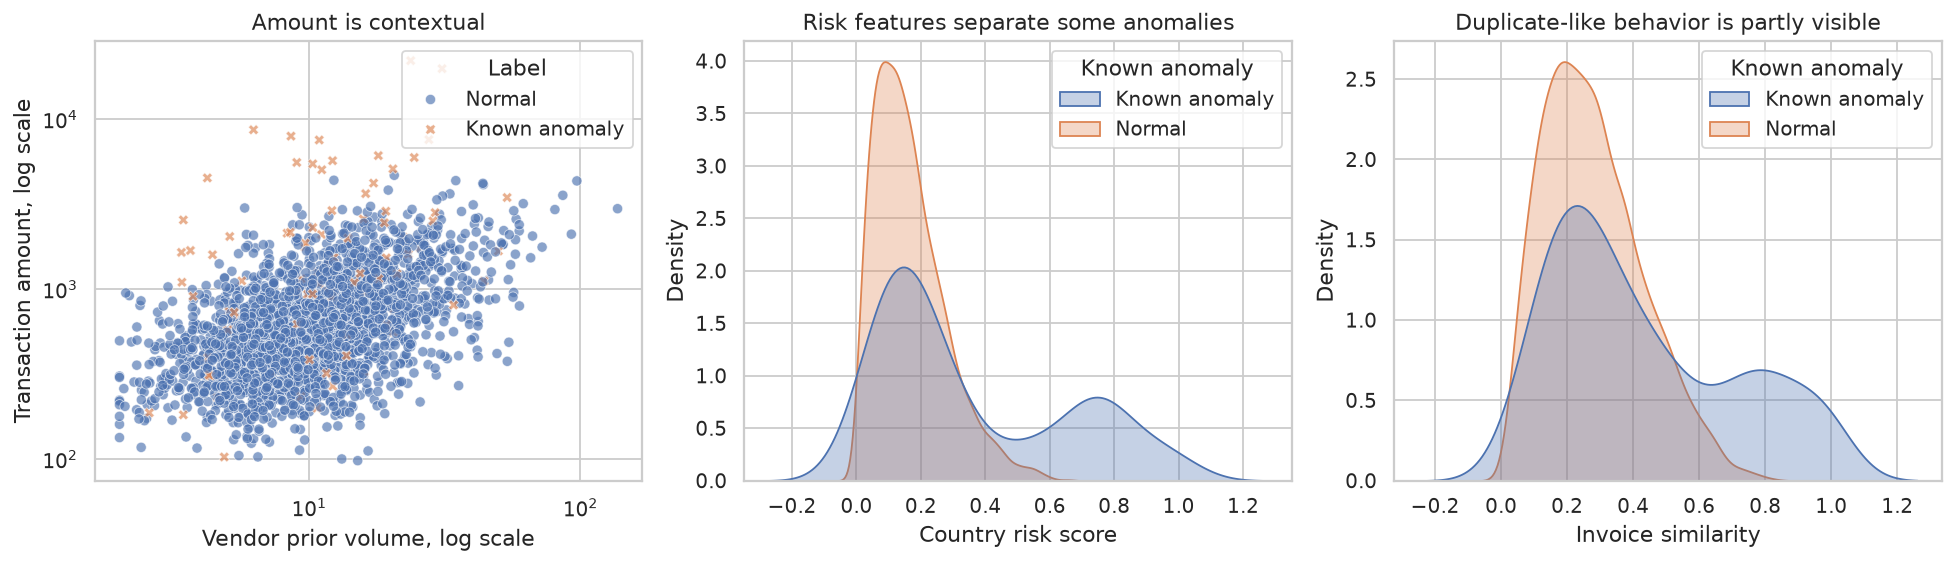

In [4]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.5))

plot_df = df.copy()
plot_df['Known anomaly'] = np.where(plot_df['true_anomaly'] == 1, 'Known anomaly', 'Normal')

sns.scatterplot(
    data=plot_df.sample(2200, random_state=RANDOM_SEED),
    x='vendor_prior_volume',
    y='amount',
    hue='Known anomaly',
    style='Known anomaly',
    alpha=0.65,
    s=32,
    ax=axes[0],
)
axes[0].set_yscale('log')
axes[0].set_xscale('log')
axes[0].set_title('Amount is contextual')
axes[0].set_xlabel('Vendor prior volume, log scale')
axes[0].set_ylabel('Transaction amount, log scale')
axes[0].legend(title='Label')

sns.kdeplot(data=plot_df, x='country_risk', hue='Known anomaly', common_norm=False, fill=True, alpha=0.32, ax=axes[1])
axes[1].set_title('Risk features separate some anomalies')
axes[1].set_xlabel('Country risk score')
axes[1].set_ylabel('Density')

sns.kdeplot(data=plot_df, x='invoice_similarity', hue='Known anomaly', common_norm=False, fill=True, alpha=0.32, ax=axes[2])
axes[2].set_title('Duplicate-like behavior is partly visible')
axes[2].set_xlabel('Invoice similarity')
axes[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

The scatterplot shows why context matters. A transaction that looks large for a small vendor may be ordinary for an enterprise vendor. The density plots show that risk and similarity variables help detect non-amount anomalies, but they are not perfect. Anomaly detection is rarely a single-feature task.

This is why anomaly detection systems often combine several kinds of evidence: value deviation, peer comparison, historical deviation, sequence behavior, and workflow constraints.

## 4. Three Scores: Naive, Contextual, and Composite

We will build three scores.

### Score 1: Naive amount score

A naive detector flags transactions with globally unusual amount:

$$
s_i^{\mathrm{amount}} = |z_i|, \qquad z_i = \frac{\log(\mathrm{amount}_i) - \mathrm{median}(\log(\mathrm{amount}))}{1.4826 \cdot \mathrm{MAD}(\log(\mathrm{amount}))}.
$$

This score is simple, but it ignores vendor context.

### Score 2: Contextual residual score

A contextual detector first predicts expected log amount from transaction context:

$$
\widehat{\log(\mathrm{amount})}_i = \hat m(c_i),
$$

then scores the residual:

$$
s_i^{\mathrm{context}} = \left|\frac{\log(\mathrm{amount})_i - \hat m(c_i)}{\widehat{\sigma}_{\mathrm{resid}}}\right|.
$$

### Score 3: Composite operational score

A production alert may combine amount deviation with access risk and collective behavior:

$$
s_i^{\mathrm{composite}} =
0.45 \tilde s_i^{\mathrm{context}}
+ 0.20 \tilde r_i^{\mathrm{country}}
+ 0.20 \tilde r_i^{\mathrm{device}}
+ 0.15 \tilde b_i^{\mathrm{duplicate}},
$$

where tildes denote standardized components. This is not an optimal detector. It is a transparent teaching baseline that makes the decision logic visible.

In [5]:
# Section focus: Score 3: Composite operational score.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

score_df = df.copy()
score_df['amount_score'] = np.abs(robust_z(score_df['log_amount']))

context_features = [
    'vendor_prior_volume',
    'vendor_history_months',
    'account_tenure_months',
    'weekday',
    'hour',
]
context_design = pd.get_dummies(
    score_df[context_features + ['vendor_segment', 'channel']],
    columns=['vendor_segment', 'channel'],
    drop_first=True,
)

train_context = score_df['true_anomaly'] == 0
context_model = make_pipeline(StandardScaler(), LinearRegression())
context_model.fit(context_design.loc[train_context], score_df.loc[train_context, 'log_amount'])

score_df['expected_log_amount_hat'] = context_model.predict(context_design)
score_df['amount_residual'] = score_df['log_amount'] - score_df['expected_log_amount_hat']
resid_scale = 1.4826 * np.median(np.abs(score_df.loc[train_context, 'amount_residual'] - score_df.loc[train_context, 'amount_residual'].median()))
score_df['contextual_amount_score'] = np.abs(score_df['amount_residual'] / resid_scale)

score_df['duplicate_signal'] = 0.5 * robust_z(score_df['recent_vendor_count']) + 0.5 * robust_z(score_df['invoice_similarity'])
components = pd.DataFrame({
    'contextual_amount_score': score_df['contextual_amount_score'],
    'country_risk': score_df['country_risk'],
    'device_risk': score_df['device_risk'],
    'duplicate_signal': score_df['duplicate_signal'],
})
standardized_components = (components - components.mean()) / components.std(ddof=0)
score_df['composite_score'] = (
    0.45 * standardized_components['contextual_amount_score']
    + 0.20 * standardized_components['country_risk']
    + 0.20 * standardized_components['device_risk']
    + 0.15 * standardized_components['duplicate_signal']
)

score_columns = ['amount_score', 'contextual_amount_score', 'composite_score']
score_auc = pd.DataFrame({
    'score': score_columns,
    'roc_auc': [roc_auc_score(score_df['true_anomaly'], score_df[col]) for col in score_columns],
    'average_precision': [average_precision_score(score_df['true_anomaly'], score_df[col]) for col in score_columns],
})
smart_display(score_auc.round(3), max_width='620px')

,score,roc_auc,average_precision
0,amount_score,0.674,0.262
1,contextual_amount_score,0.705,0.413
2,composite_score,0.959,0.749


The ranking metrics compare how well each score separates known anomalies from normal cases. ROC AUC measures broad ranking quality across thresholds. Average precision is especially relevant when anomalies are rare because it focuses on the precision-recall curve.

The naive amount score should identify extreme amounts, but it should struggle with access-risk and duplicate-burst anomalies. The contextual amount score improves the amount-spike problem by comparing transactions to peer and history baselines. The composite score should perform best overall because it includes several anomaly mechanisms.

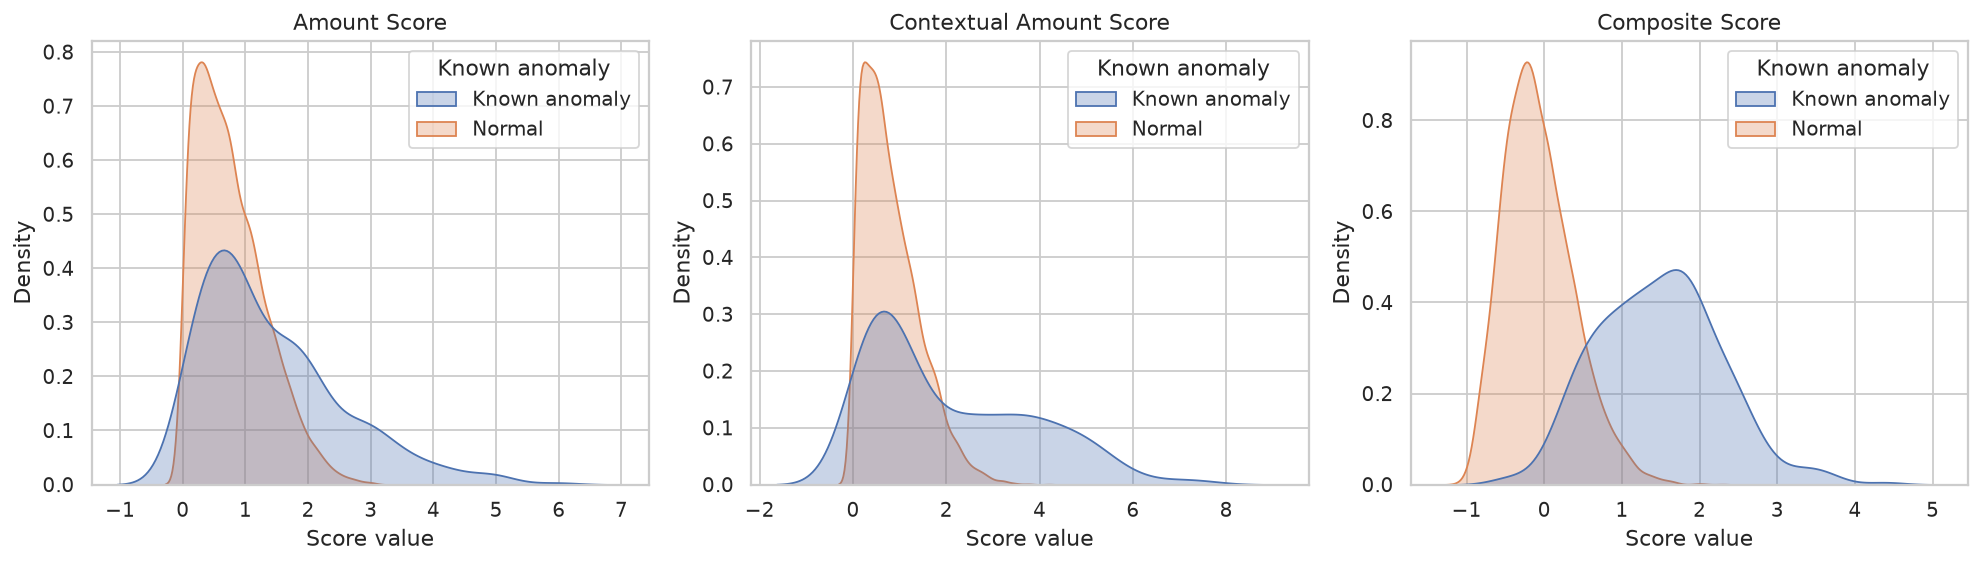

In [6]:
# Section focus: Discussion.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

score_long = score_df.melt(
    id_vars=['true_anomaly', 'anomaly_type'],
    value_vars=score_columns,
    var_name='score_name',
    value_name='score_value',
)
score_long['Known anomaly'] = np.where(score_long['true_anomaly'] == 1, 'Known anomaly', 'Normal')

fig, axes = plt.subplots(1, 3, figsize=(15.4, 4.5))
for ax, score_name in zip(axes, score_columns):
    sns.kdeplot(
        data=score_long.loc[score_long['score_name'] == score_name],
        x='score_value',
        hue='Known anomaly',
        common_norm=False,
        fill=True,
        alpha=0.30,
        ax=ax,
    )
    ax.set_title(score_name.replace('_', ' ').title())
    ax.set_xlabel('Score value')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

Read the result through the lens of alert quality. In Score 3: Composite operational score, high scores, unusual clusters, or shifted distributions should be connected to the cost of missed incidents and false alarms. A useful detector is one whose outputs can be investigated, explained, and governed.


## 5. Thresholds, Capacity, and Error Costs

A threshold turns a score into an alert:

$$
d_i(t) = \mathbf{1}\{s_i \ge t\}.
$$

For a known anomaly indicator $Y_i \in \{0,1\}$, the usual alert quantities are

$$
\mathrm{precision}(t) = \Pr(Y=1 \mid d(t)=1),
$$

$$
\mathrm{recall}(t) = \Pr(d(t)=1 \mid Y=1),
$$

and

$$
\text{review rate}(t) = \Pr(d(t)=1).
$$

But a decision system also needs a utility model. One simple form is

$$
U_i(t) = b \cdot \mathbf{1}\{d_i(t)=1, Y_i=1\}
- c_{\mathrm{fp}} \cdot \mathbf{1}\{d_i(t)=1, Y_i=0\}
- c_{\mathrm{fn}} \cdot \mathbf{1}\{d_i(t)=0, Y_i=1\}.
$$

Here $b$ is the value of catching a true anomaly, $c_{\mathrm{fp}}$ is the cost of a false alert, and $c_{\mathrm{fn}}$ is the cost of missing an anomaly. These values are not universal. They come from the operating environment.

In [7]:
# Section focus: 5. Thresholds, Capacity, and Error Costs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def threshold_table(frame, score_col, y_col='true_anomaly', n_thresholds=120, benefit_tp=6.0, cost_fp=0.7, cost_fn=4.0):
    """Carry out the threshold table step used in the 01. Anomaly Detection for Decision Science workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    y_col : object
        Column name containing the outcome or target used by the model.
    n_thresholds : object
        Count or size setting for the threshold table calculation.
    benefit_tp : object
        Operational value used to translate predictions into decision consequences.
    cost_fp : object
        Cost value used to translate model errors into operational consequences.
    cost_fn : object
        Cost value used to translate model errors into operational consequences.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the threshold table workflow for later analysis.
    """
    scores = frame[score_col].to_numpy()
    y = frame[y_col].to_numpy()
    thresholds = np.quantile(scores, np.linspace(0.70, 0.995, n_thresholds))
    rows = []
    for threshold in thresholds:
        alert = scores >= threshold
        tp = int(((alert == 1) & (y == 1)).sum())
        fp = int(((alert == 1) & (y == 0)).sum())
        fn = int(((alert == 0) & (y == 1)).sum())
        alerts = int(alert.sum())
        rows.append({
            'threshold': threshold,
            'alerts': alerts,
            'review_rate': alerts / len(frame),
            'precision': tp / alerts if alerts else np.nan,
            'recall': tp / y.sum(),
            'false_alerts': fp,
            'missed_anomalies': fn,
            'mean_utility': (benefit_tp * tp - cost_fp * fp - cost_fn * fn) / len(frame),
        })
    return pd.DataFrame(rows).drop_duplicates('alerts')

policy_table = threshold_table(score_df, 'composite_score')
best_policy = policy_table.loc[policy_table['mean_utility'].idxmax()].copy()
capacity_alerts = int(np.ceil(0.04 * len(score_df)))
capacity_policy = policy_table.iloc[(policy_table['alerts'] - capacity_alerts).abs().argsort()[:1]].iloc[0].copy()

policy_summary = pd.DataFrame({
    'Policy': ['Utility-maximizing threshold', 'Approximate 4% review-capacity threshold'],
    'Threshold': [best_policy['threshold'], capacity_policy['threshold']],
    'Alerts': [best_policy['alerts'], capacity_policy['alerts']],
    'Review rate': [best_policy['review_rate'], capacity_policy['review_rate']],
    'Precision': [best_policy['precision'], capacity_policy['precision']],
    'Recall': [best_policy['recall'], capacity_policy['recall']],
    'Mean utility': [best_policy['mean_utility'], capacity_policy['mean_utility']],
})
policy_display = policy_summary.copy()
policy_display['Threshold'] = policy_display['Threshold'].map(lambda value: f'{value:.3f}')
policy_display['Alerts'] = policy_display['Alerts'].astype(int)
for column in ['Review rate', 'Precision', 'Recall']:
    policy_display[column] = policy_display[column].map(lambda value: f'{value:.1%}')
policy_display['Mean utility'] = policy_display['Mean utility'].map(lambda value: f'{value:.3f}')

smart_display(policy_display, max_width='900px')

,Policy,Threshold,Alerts,Review rate,Precision,Recall,Mean utility
0,Utility-maximizing threshold,0.637,786,10.9%,36.3%,84.3%,0.159
1,Approximate 4% review-capacity threshold,1.153,286,4.0%,75.5%,63.9%,0.105


For Thresholds, Capacity, and Error Costs, judge the output by whether it improves the alert queue for a real reviewer. The useful signal is the one that separates review-worthy risk from routine variation, measurement noise, and expected seasonality.


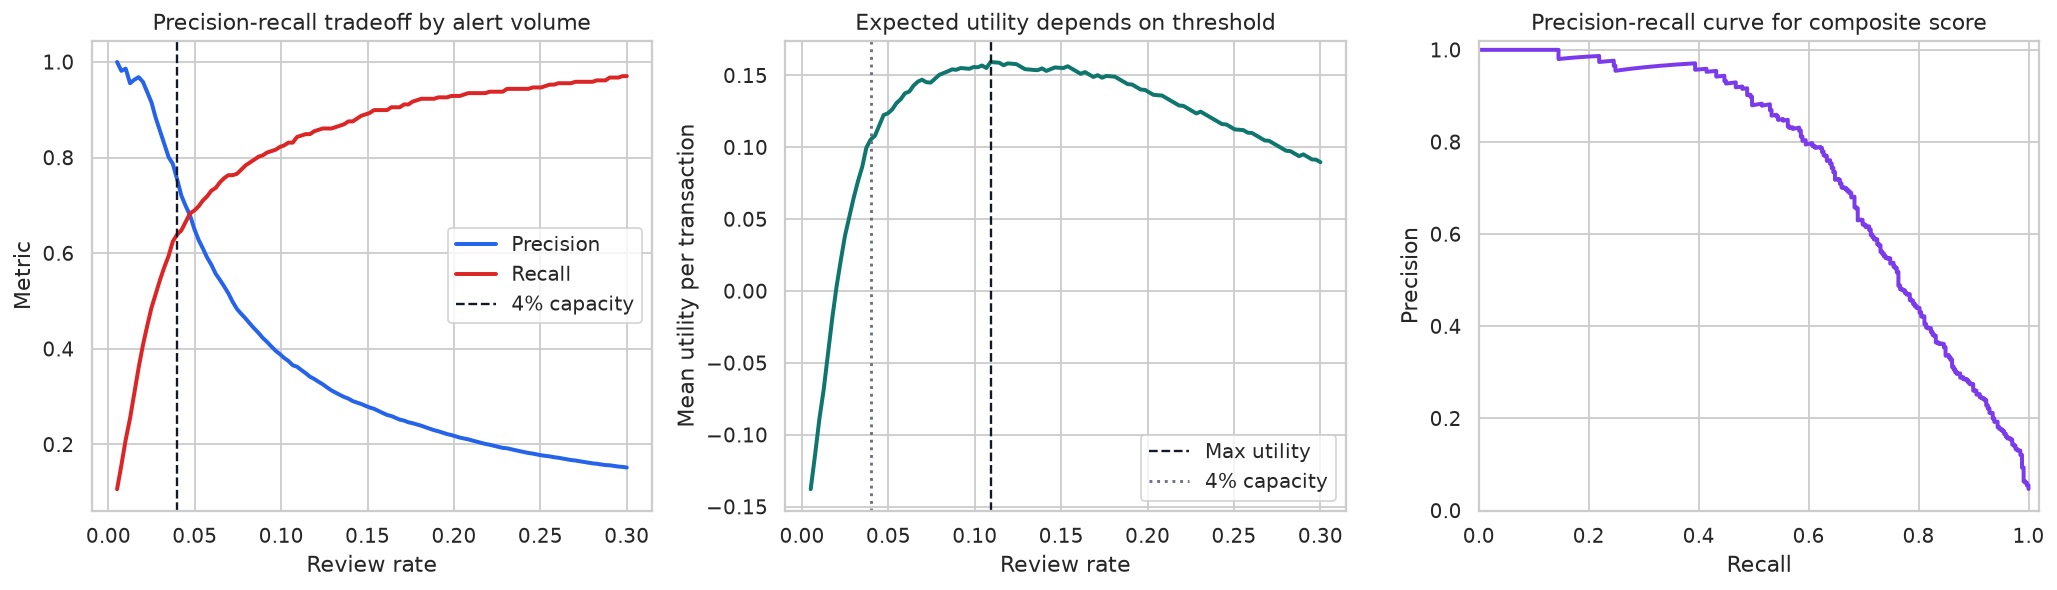

In [8]:
# Section focus: 5. Thresholds, Capacity, and Error Costs.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.7))

axes[0].plot(policy_table['review_rate'], policy_table['precision'], color='#2563eb', linewidth=2.2, label='Precision')
axes[0].plot(policy_table['review_rate'], policy_table['recall'], color='#dc2626', linewidth=2.2, label='Recall')
axes[0].axvline(capacity_policy['review_rate'], color='#111827', linestyle='--', linewidth=1.3, label='4% capacity')
axes[0].set_title('Precision-recall tradeoff by alert volume')
axes[0].set_xlabel('Review rate')
axes[0].set_ylabel('Metric')
axes[0].legend()

axes[1].plot(policy_table['review_rate'], policy_table['mean_utility'], color='#0f766e', linewidth=2.2)
axes[1].axvline(best_policy['review_rate'], color='#111827', linestyle='--', linewidth=1.3, label='Max utility')
axes[1].axvline(capacity_policy['review_rate'], color='#6b7280', linestyle=':', linewidth=1.6, label='4% capacity')
axes[1].set_title('Expected utility depends on threshold')
axes[1].set_xlabel('Review rate')
axes[1].set_ylabel('Mean utility per transaction')
axes[1].legend()

precision, recall, pr_thresholds = precision_recall_curve(score_df['true_anomaly'], score_df['composite_score'])
axes[2].plot(recall, precision, color='#7c3aed', linewidth=2.2)
axes[2].set_title('Precision-recall curve for composite score')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_xlim(0, 1.02)
axes[2].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

The threshold table and plots make the operational tension visible.

- Lower thresholds review more transactions and catch more anomalies, but they increase false alerts.
- Higher thresholds preserve analyst capacity and increase precision, but they miss more anomalies.
- A utility-maximizing threshold can differ from a capacity threshold if the cost model and staffing constraint disagree.

This is why threshold design should not be hidden inside a modeling notebook. It belongs in the decision record.

## 6. What Gets Alerted?

We now inspect the top of the alert queue under the capacity policy. This is an analyst-experience check as well as a technical check. If the top alerts are not interpretable, operational teams will not trust the detector.

In [9]:
# Section focus: 6. What Gets Alerted?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

score_df['alert_capacity_policy'] = (score_df['composite_score'] >= capacity_policy['threshold']).astype(int)
score_df['alert_utility_policy'] = (score_df['composite_score'] >= best_policy['threshold']).astype(int)

component_columns = ['contextual_amount_score', 'country_risk', 'device_risk', 'duplicate_signal']
component_display = standardized_components.rename(columns={
    'contextual_amount_score': 'amount_context_component',
    'country_risk': 'country_risk_component',
    'device_risk': 'device_risk_component',
    'duplicate_signal': 'duplicate_component',
})
queue_df = pd.concat([score_df, component_display], axis=1)

alert_mix = (
    queue_df.loc[queue_df['alert_capacity_policy'] == 1]
    .groupby('anomaly_type')
    .agg(count=('true_anomaly', 'size'), anomaly_rate=('true_anomaly', 'mean'))
    .reset_index()
    .sort_values('count', ascending=False)
)
alert_mix['share_of_alerts'] = alert_mix['count'] / alert_mix['count'].sum()

queue_preview = (
    queue_df.sort_values('composite_score', ascending=False)
    .head(12)[[
        'vendor_segment', 'channel', 'hour', 'amount', 'country_risk', 'device_risk',
        'invoice_similarity', 'recent_vendor_count', 'contextual_amount_score',
        'composite_score', 'anomaly_type', 'true_anomaly',
    ]]
)

alert_mix_display = alert_mix.copy()
alert_mix_display['anomaly_rate'] = alert_mix_display['anomaly_rate'].map(lambda value: f'{value:.1%}')
alert_mix_display['share_of_alerts'] = alert_mix_display['share_of_alerts'].map(lambda value: f'{value:.1%}')

queue_preview_display = queue_preview.copy()
numeric_preview_cols = queue_preview_display.select_dtypes(include='number').columns
queue_preview_display[numeric_preview_cols] = queue_preview_display[numeric_preview_cols].round(3)

smart_display(alert_mix_display, max_width='620px')
smart_display(queue_preview_display, max_width='110px')

,anomaly_type,count,anomaly_rate,share_of_alerts
0,amount_spike,101,100.0%,35.3%
3,risky_access,93,100.0%,32.5%
2,normal,70,0.0%,24.5%
1,duplicate_burst,22,100.0%,7.7%


,vendor_segment,channel,hour,amount,country_risk,device_risk,invoice_similarity,recent_vendor_count,contextual_amount_score,composite_score,anomaly_type,true_anomaly
1522,enterprise_vendor,api,14,45717.176,0.498,0.085,0.306,2,7.582,4.391,amount_spike,1
4768,mid_market_vendor,portal,2,22191.071,0.218,0.170,0.099,0,7.289,3.698,amount_spike,1
2852,small_vendor,batch_upload,23,2399.230,0.857,0.895,0.063,1,3.553,3.634,risky_access,1
4254,mid_market_vendor,api,17,22165.063,0.122,0.046,0.484,3,7.070,3.605,amount_spike,1
1496,small_vendor,portal,3,4472.124,0.358,0.268,0.494,1,5.876,3.495,amount_spike,1
5394,small_vendor,api,18,4835.402,0.439,0.197,0.272,3,5.677,3.386,amount_spike,1
4487,small_vendor,api,3,102.921,0.920,0.982,0.088,1,2.715,3.383,risky_access,1
6020,mid_market_vendor,api,10,21435.269,0.034,0.147,0.306,1,6.918,3.330,amount_spike,1
1816,small_vendor,api,20,5676.189,0.096,0.038,0.598,4,6.327,3.230,amount_spike,1
2949,enterprise_vendor,api,4,22336.850,0.310,0.109,0.396,1,5.968,3.174,amount_spike,1


What Gets Alerted? should be read as an operations question. Ask whether the score isolates a real review priority or mostly reflects routine variation and noise.


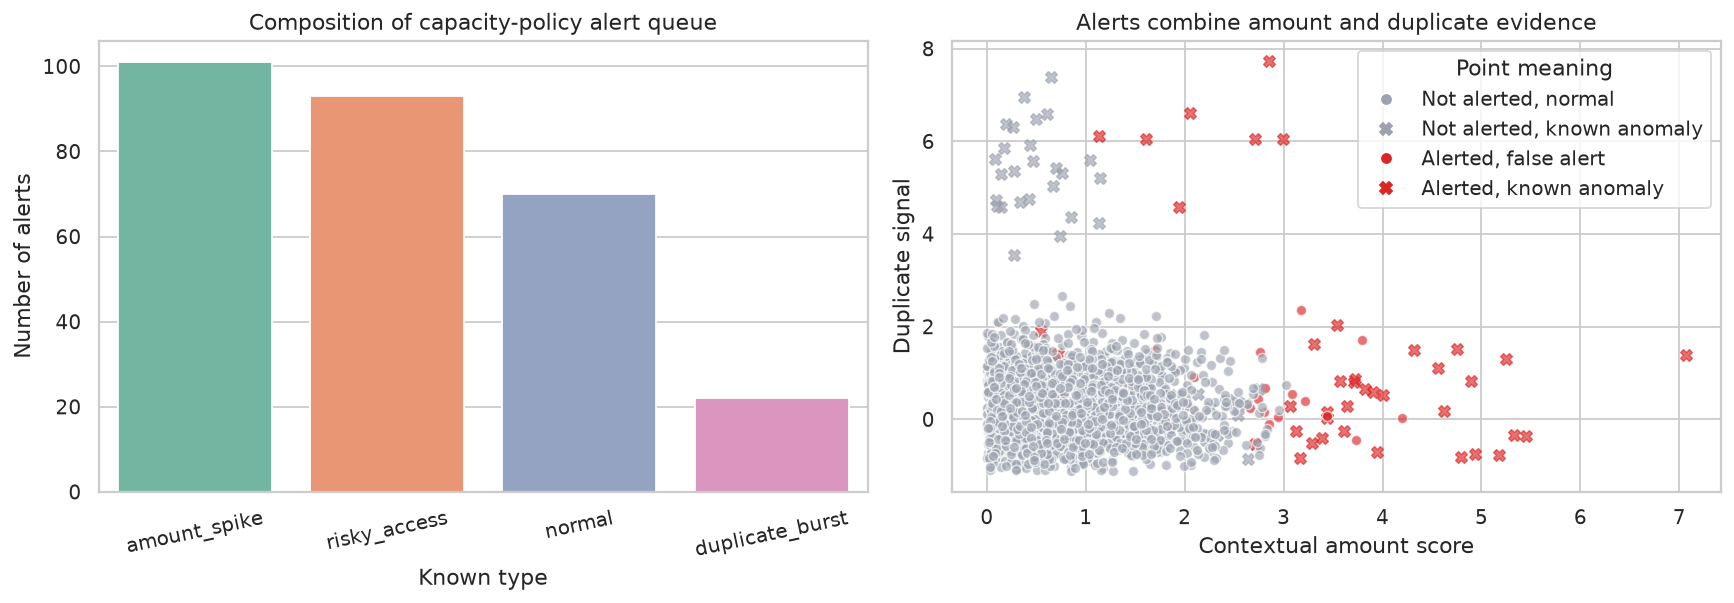

In [10]:
# Section focus: 6. What Gets Alerted?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

mix_plot = alert_mix.copy()
sns.barplot(data=mix_plot, x='anomaly_type', y='count', hue='anomaly_type', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Composition of capacity-policy alert queue')
axes[0].set_xlabel('Known type')
axes[0].set_ylabel('Number of alerts')
axes[0].tick_params(axis='x', rotation=12)

scatter_sample = queue_df.sample(2500, random_state=RANDOM_SEED).copy()
scatter_sample['Alert decision'] = np.where(scatter_sample['alert_capacity_policy'] == 1, 'Alerted', 'Not alerted')
scatter_sample['Known label'] = np.where(scatter_sample['true_anomaly'] == 1, 'Known anomaly', 'Normal')

marker_map = {'Normal': 'o', 'Known anomaly': 'X'}
color_map = {'Not alerted': '#9ca3af', 'Alerted': '#dc2626'}

for (alert_decision, known_label), group in scatter_sample.groupby(['Alert decision', 'Known label']):
    axes[1].scatter(
        group['contextual_amount_score'],
        group['duplicate_signal'],
        c=color_map[alert_decision],
        marker=marker_map[known_label],
        alpha=0.65,
        s=32 if known_label == 'Normal' else 42,
        linewidths=0.8,
        edgecolors='white' if known_label == 'Normal' else color_map[alert_decision],
    )

legend_handles = [
    Line2D([0], [0], marker='o', color='white', label='Not alerted, normal', markerfacecolor='#9ca3af', markeredgecolor='white', markersize=7),
    Line2D([0], [0], marker='X', color='#9ca3af', label='Not alerted, known anomaly', markerfacecolor='#9ca3af', markeredgecolor='#9ca3af', markersize=7, linestyle='None'),
    Line2D([0], [0], marker='o', color='white', label='Alerted, false alert', markerfacecolor='#dc2626', markeredgecolor='white', markersize=7),
    Line2D([0], [0], marker='X', color='#dc2626', label='Alerted, known anomaly', markerfacecolor='#dc2626', markeredgecolor='#dc2626', markersize=7, linestyle='None'),
]
axes[1].set_title('Alerts combine amount and duplicate evidence')
axes[1].set_xlabel('Contextual amount score')
axes[1].set_ylabel('Duplicate signal')
axes[1].legend(handles=legend_handles, title='Point meaning', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

The alert queue is intentionally heterogeneous. Some alerts are large relative to context. Others are not the largest transactions, but they combine risky access features with duplicate-like behavior. This is closer to what operational anomaly detection feels like in practice: alerts are often triggered by combinations of weak signals rather than one obvious outlier.

The false alerts are also informative. A false alert may reveal a legitimate but unusual transaction, a stale baseline, a missing feature, or a business process that needs its own exception rule.

## 7. Segment-Specific Review Rates

A single global threshold can allocate review unevenly across contexts. That may be correct if risk truly differs by segment, but it may also create workflow or fairness concerns.

For an alert rule $d_i(t)$, the segment review rate is

$$
\Pr(d(t)=1 \mid G=g),
$$

where $G$ is a segment such as vendor type or channel. A governance review should ask whether differences in alert rates are expected, justified, and monitored.

In [11]:
# Section focus: 7. Segment-Specific Review Rates.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

segment_audit = (
    queue_df
    .groupby('vendor_segment')
    .agg(
        transactions=('true_anomaly', 'size'),
        known_anomaly_rate=('true_anomaly', 'mean'),
        alert_rate=('alert_capacity_policy', 'mean'),
        precision_among_alerts=('true_anomaly', lambda s: np.nan),
    )
    .reset_index()
)

precision_by_segment = []
for segment, group in queue_df.groupby('vendor_segment'):
    alerted = group.loc[group['alert_capacity_policy'] == 1]
    precision_by_segment.append({
        'vendor_segment': segment,
        'precision_among_alerts': alerted['true_anomaly'].mean() if len(alerted) else np.nan,
    })
precision_by_segment = pd.DataFrame(precision_by_segment)
segment_audit = segment_audit.drop(columns=['precision_among_alerts']).merge(precision_by_segment, on='vendor_segment')

channel_audit = (
    queue_df
    .groupby('channel')
    .agg(
        transactions=('true_anomaly', 'size'),
        known_anomaly_rate=('true_anomaly', 'mean'),
        alert_rate=('alert_capacity_policy', 'mean'),
    )
    .reset_index()
)

segment_audit_display = segment_audit.copy()
for column in ['known_anomaly_rate', 'alert_rate', 'precision_among_alerts']:
    segment_audit_display[column] = segment_audit_display[column].map(lambda value: f'{value:.1%}' if pd.notna(value) else '')

channel_audit_display = channel_audit.copy()
for column in ['known_anomaly_rate', 'alert_rate']:
    channel_audit_display[column] = channel_audit_display[column].map(lambda value: f'{value:.1%}')

smart_display(segment_audit_display, max_width='760px')
smart_display(channel_audit_display, max_width='620px')

,vendor_segment,transactions,known_anomaly_rate,alert_rate,precision_among_alerts
0,enterprise_vendor,1105,4.1%,4.2%,78.3%
1,mid_market_vendor,2414,4.0%,3.8%,72.5%
2,small_vendor,3681,5.4%,4.0%,76.5%


,channel,transactions,known_anomaly_rate,alert_rate
0,api,3263,4.2%,3.7%
1,batch_upload,1217,5.8%,4.7%
2,portal,2720,4.8%,4.0%


In Segment-Specific Review Rates, the detector earns its keep only if the output sharpens the review queue.


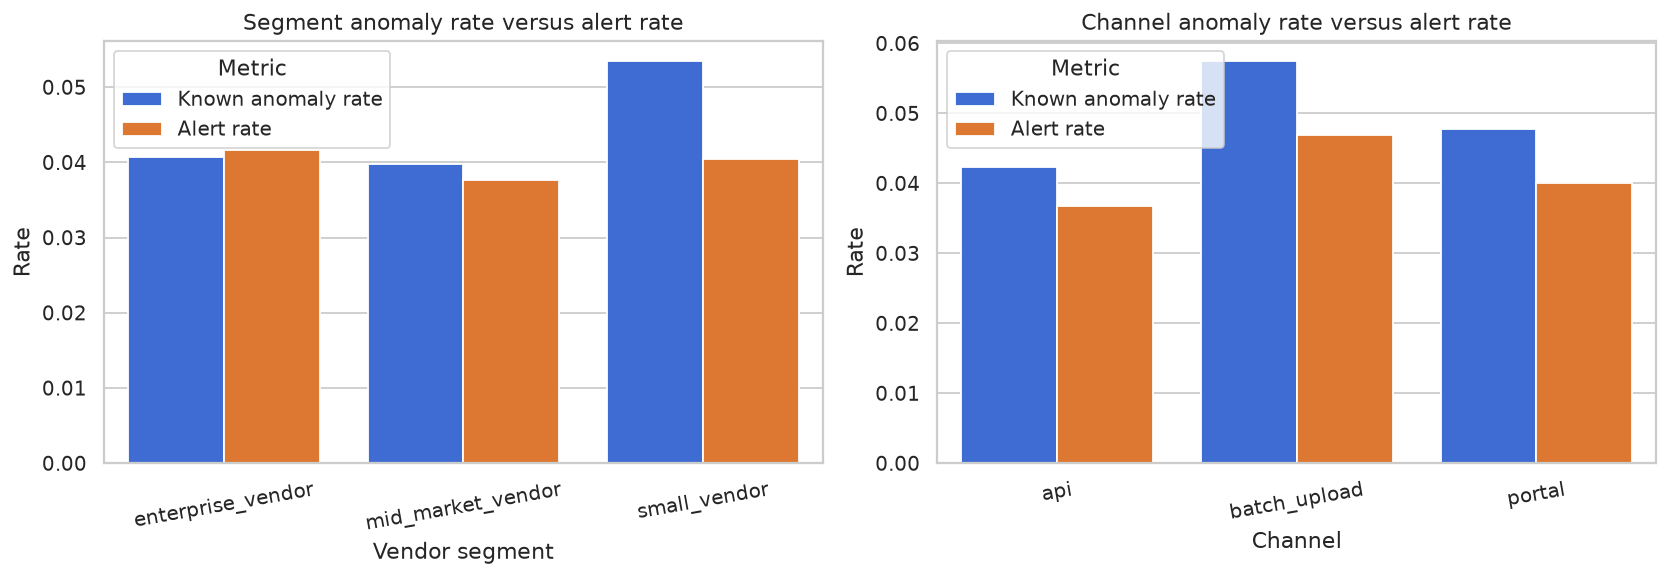

In [12]:
# Section focus: 7. Segment-Specific Review Rates.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

segment_plot = segment_audit.melt(
    id_vars='vendor_segment',
    value_vars=['known_anomaly_rate', 'alert_rate'],
    var_name='metric',
    value_name='rate',
)
metric_labels = {'known_anomaly_rate': 'Known anomaly rate', 'alert_rate': 'Alert rate'}
segment_plot['metric'] = segment_plot['metric'].map(metric_labels)
sns.barplot(data=segment_plot, x='vendor_segment', y='rate', hue='metric', ax=axes[0], palette=['#2563eb', '#f97316'])
axes[0].set_title('Segment anomaly rate versus alert rate')
axes[0].set_xlabel('Vendor segment')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=10)
axes[0].legend(title='Metric')

channel_plot = channel_audit.melt(
    id_vars='channel',
    value_vars=['known_anomaly_rate', 'alert_rate'],
    var_name='metric',
    value_name='rate',
)
channel_plot['metric'] = channel_plot['metric'].map(metric_labels)
sns.barplot(data=channel_plot, x='channel', y='rate', hue='metric', ax=axes[1], palette=['#2563eb', '#f97316'])
axes[1].set_title('Channel anomaly rate versus alert rate')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Rate')
axes[1].tick_params(axis='x', rotation=10)
axes[1].legend(title='Metric')

plt.tight_layout()
plt.show()

Segment audit tables help separate three possibilities:

1. A segment is truly riskier and should receive more review.
2. A segment is being over-alerted because the score is poorly calibrated for that context.
3. A segment is being under-alerted because the detector misses its anomaly mechanisms.

This is the bridge between anomaly detection and governance. A detector is not complete until its alert distribution has been checked against business context and review constraints.

## 8. Decision Memo Template

A professional anomaly-detection result should end with an operational recommendation. The memo should include the score definition, threshold, expected workload, expected alert quality, known blind spots, and monitoring plan.

In [13]:
memo = pd.DataFrame({
    'Decision item': [
        'Recommended initial policy',
        'Reason for using the composite score',
        'Expected review load',
        'Expected alert precision',
        'Expected anomaly coverage',
        'Primary operational risk',
        'Governance check',
        'Next iteration',
    ],
    'Recommendation': [
        'Use the capacity threshold as a pilot policy, then revisit after analyst feedback.',
        'It combines contextual amount deviation, access risk, and duplicate-like behavior rather than relying on global amount alone.',
        f"About {capacity_policy['review_rate']:.1%} of transactions enter the queue.",
        f"Estimated precision is {capacity_policy['precision']:.1%} in this teaching sample.",
        f"Estimated recall is {capacity_policy['recall']:.1%} in this teaching sample.",
        'False alerts can consume analyst capacity; missed anomalies remain possible for mechanisms not represented in the score.',
        'Audit alert rates by vendor segment and channel before deployment.',
        'Collect analyst dispositions and build mechanism-specific detectors in later notebooks.',
    ],
})
smart_display(memo, max_width='760px')

,Decision item,Recommendation
0,Recommended initial policy,"Use the capacity threshold as a pilot policy, then revisit after analyst feedback."
1,Reason for using the composite score,"It combines contextual amount deviation, access risk, and duplicate-like behavior rather than relying on global amount alone."
2,Expected review load,About 4.0% of transactions enter the queue.
3,Expected alert precision,Estimated precision is 75.5% in this teaching sample.
4,Expected anomaly coverage,Estimated recall is 63.9% in this teaching sample.
5,Primary operational risk,False alerts can consume analyst capacity; missed anomalies remain possible for mechanisms not represented in the score.
6,Governance check,Audit alert rates by vendor segment and channel before deployment.
7,Next iteration,Collect analyst dispositions and build mechanism-specific detectors in later notebooks.


The practical reading of Decision Memo Template is whether the flagged cases point to an action a team can defend.


## 9. What This First Notebook Establishes

This notebook deliberately used transparent scores rather than advanced algorithms. That is the right starting point. Before using isolation forests, one-class SVMs, density models, autoencoders, or sequence models, we need a disciplined answer to four questions:

1. What is the unit of alerting?
2. What is the relevant normal baseline?
3. What is the threshold policy?
4. What happens after an alert fires?

Those questions will organize the rest of the course.

## Key Takeaways

- Anomaly detection is a score-and-decision problem as well as a model-fitting problem.
- A global outlier can differ from a contextual anomaly; the baseline determines the interpretation.
- Rare-event base rates make precision and alert volume central operational metrics.
- Thresholds should be chosen with costs, capacity, and governance constraints in view.
- Analyst-facing explanations should describe why an alert fired and what review action follows.
- Segment-level alert audits are part of responsible anomaly-detection deployment.

## References

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Hodge, V. J., & Austin, J. (2004). A survey of outlier detection methodologies. *Artificial Intelligence Review, 22*(2), 85-126. [https://doi.org/10.1023/B:AIRE.0000045502.10941.a9](https://doi.org/10.1023/B:AIRE.0000045502.10941.a9)

Siffer, A., Fouque, P.-A., Termier, A., & Largouet, C. (2017). Anomaly detection in streams with extreme value theory. *Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1067-1075. [https://doi.org/10.1145/3097983.3098144](https://doi.org/10.1145/3097983.3098144)
